In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [90]:
import math

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out


    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)

    def __rsub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return other + (-self)




    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers supported"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)

        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

#Taking an example for understanding the process and then the visualisation
a = Value(2.0, label  = 'a')
b = Value(-4.0, label  = 'b')
c = Value(12.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(6.0, label = 'f')
L = d*f; L.label = 'L'
L

Value(data=24.0, grad=0.0)

In [51]:
from graphviz import Digraph

def trace(root):
       #builds a set of all nodes and edges in a graph
       nodes, edges = set(), set()
       def build(v):
           if v not in nodes:
               nodes.add(v)
               for child in v._prev:
                   edges.add((child, v))
                   build(child)
       build(root)
       return nodes, edges
       
def draw_dot(root):
    dot = Digraph(format = 'svg',  graph_attr = {'rankdir': 'LR'})#Left to Right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any val in graph, create a rectangular node for it
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape="record")
        if n._op:
            #If this val is a result of some ops, create a node for it
            dot.node(name = uid + n._op, label  = n._op)
            #and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        #connect n1 to op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot
    

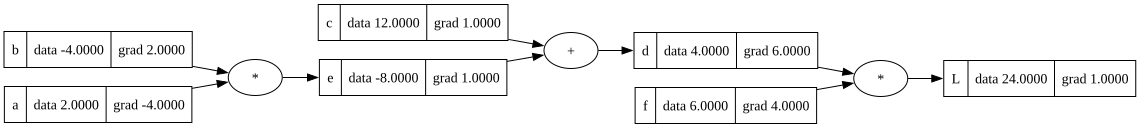

In [37]:
draw_dot(L)

In [52]:
x1 = Value(2.0, label = 'x1')
x2 = Value(4.2, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w1')
b = Value(6.9, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()

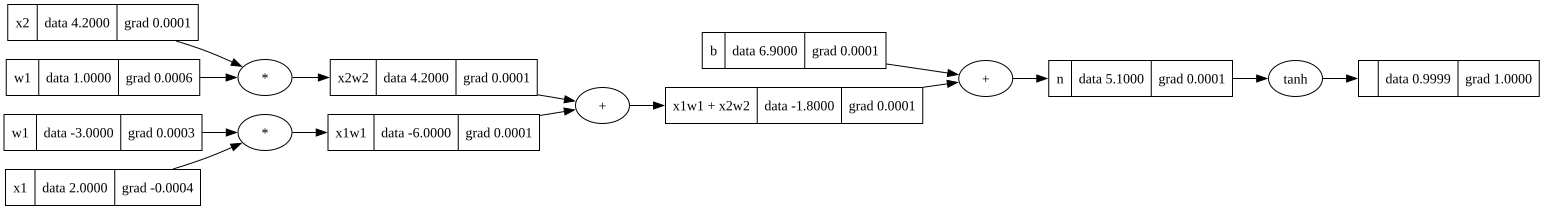

In [54]:
draw_dot(o)

In [53]:
o.backward()

In [92]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # weighted sum + bias
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
        
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


# Example
x = [Value(2.0), Value(3.0), Value(-1.0)]
n = MLP(3, [4, 4, 1])
n(x)


Value(data=-0.5640221319042914, grad=0.0)

In [93]:
#extremely simple binary classifier
xs = [
    [2.0, 3.0, -1.0],
    [4.1, -2.22, -3.0],
    [0.5, 6.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]
xs_val = [[Value(xij) for xij in xi] for xi in xs]
ypred = [n(x) for x in xs_val]
ypred

[Value(data=-0.5640221319042914, grad=0.0),
 Value(data=0.40209781865296584, grad=0.0),
 Value(data=0.0860262035901294, grad=0.0),
 Value(data=-0.35828485318664127, grad=0.0)]

In [105]:
# Training loop
for epoch in range(100):  # number of epochs
    # Forward pass
    ypred = [n(xi) for xi in xs_val]
    loss = Value(0.0)
    for ygt, yout in zip(ys_val, ypred):
        loss = loss + (yout - ygt) ** 2

    # Reset gradients before backprop
    for p in n.parameters():
        p.grad = 0.0

    # Backward pass
    loss.backward()

    # Update parameters (SGD)
    for p in n.parameters():
        p.data -= 0.05 * p.grad   # learning rate = 0.05

    # Logging
    print(f"Epoch {epoch:02d} | Loss = {loss.data:.4f}")


Epoch 00 | Loss = 0.0038
Epoch 01 | Loss = 0.0038
Epoch 02 | Loss = 0.0038
Epoch 03 | Loss = 0.0038
Epoch 04 | Loss = 0.0038
Epoch 05 | Loss = 0.0037
Epoch 06 | Loss = 0.0037
Epoch 07 | Loss = 0.0037
Epoch 08 | Loss = 0.0037
Epoch 09 | Loss = 0.0037
Epoch 10 | Loss = 0.0037
Epoch 11 | Loss = 0.0036
Epoch 12 | Loss = 0.0036
Epoch 13 | Loss = 0.0036
Epoch 14 | Loss = 0.0036
Epoch 15 | Loss = 0.0036
Epoch 16 | Loss = 0.0036
Epoch 17 | Loss = 0.0036
Epoch 18 | Loss = 0.0036
Epoch 19 | Loss = 0.0035
Epoch 20 | Loss = 0.0035
Epoch 21 | Loss = 0.0035
Epoch 22 | Loss = 0.0035
Epoch 23 | Loss = 0.0035
Epoch 24 | Loss = 0.0035
Epoch 25 | Loss = 0.0035
Epoch 26 | Loss = 0.0034
Epoch 27 | Loss = 0.0034
Epoch 28 | Loss = 0.0034
Epoch 29 | Loss = 0.0034
Epoch 30 | Loss = 0.0034
Epoch 31 | Loss = 0.0034
Epoch 32 | Loss = 0.0034
Epoch 33 | Loss = 0.0034
Epoch 34 | Loss = 0.0033
Epoch 35 | Loss = 0.0033
Epoch 36 | Loss = 0.0033
Epoch 37 | Loss = 0.0033
Epoch 38 | Loss = 0.0033
Epoch 39 | Loss = 0.0033


In [106]:
ypred

[Value(data=0.9849503117903122, grad=-0.030099376419375545),
 Value(data=-0.97014225339741, grad=0.05971549320517999),
 Value(data=-0.9697214513510334, grad=0.06055709729793324),
 Value(data=0.9742307945373195, grad=-0.051538410925360933)]

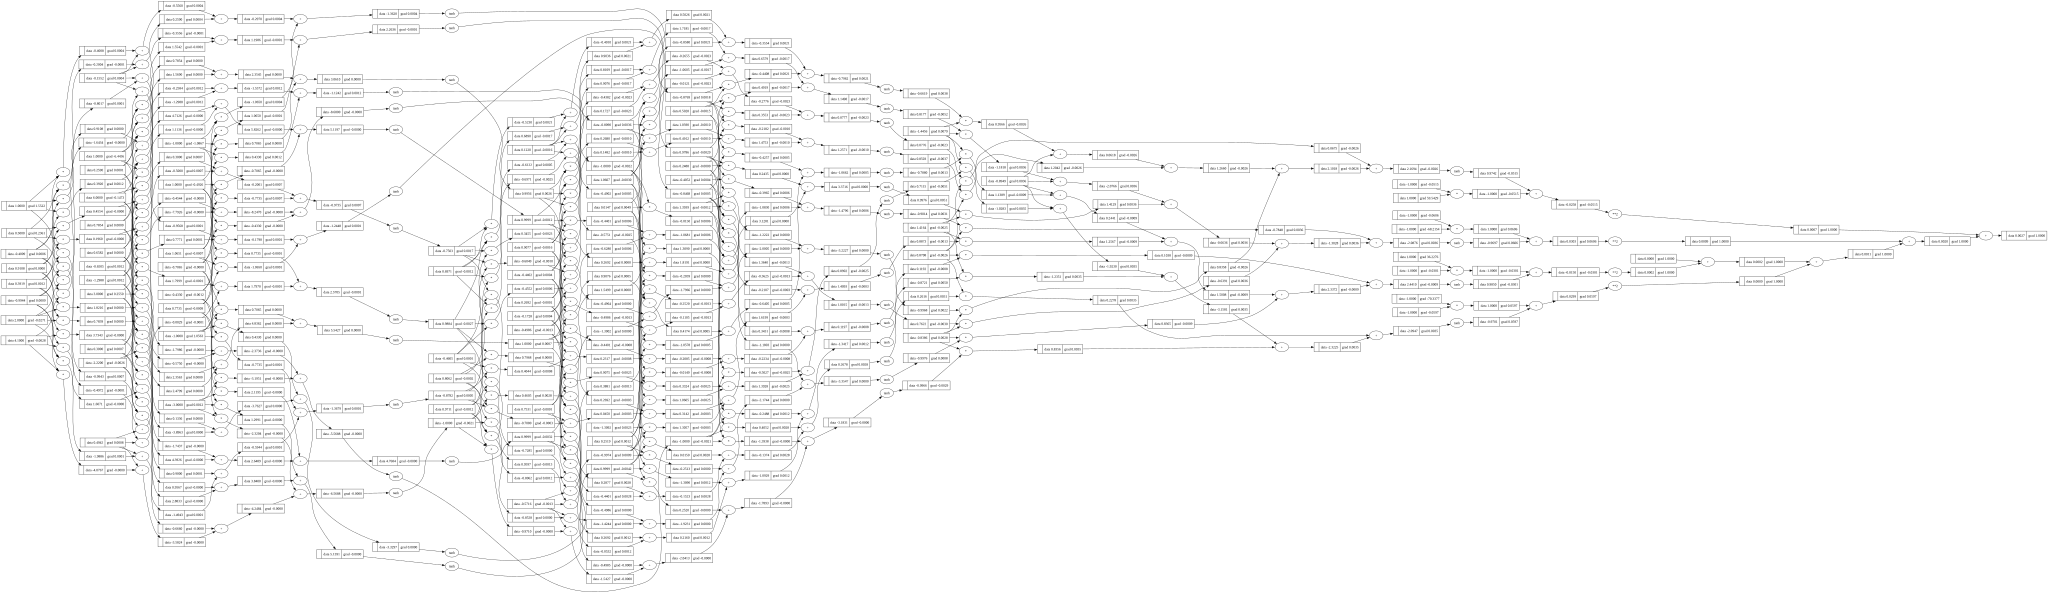

In [107]:
draw_dot(loss)

In [ ]:
#Have any more interesting ideas or extensions? Hook me up :)